<a href="https://colab.research.google.com/github/iarabertopena/ml-learning-lab/blob/main/ml_learning_lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Bibliotecas

In [1]:
%%writefile requirements.txt
numpy
pandas
scipy
scikit-learn
scikit-multilearn
matplotlib
seaborn
scikit-plot
autorank
tqdm

Writing requirements.txt


In [2]:
!pip install -r requirements.txt

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.4/89.4 kB 3.3 MB/s eta 0:00:00
  Created wheel for baycomp: filename=baycomp-1.0.3-py3-none-any.whl size=18027 sha256=7661e264fd6cb67980f10b4804a3dc068c2e8f9380c7c22c483158aea1f5e22b
  Stored in directory: /root/.cache/pip/wheels/ff/39/6a/f87e05ad75b9d87f4eb262a897ec2fe3aab09449d13e3c3b2c
Successfully built baycomp


### Imports

In [3]:
import numpy as np
import pandas as pd

from sklearn import metrics
from sklearn.model_selection import StratifiedKFold
from skmultilearn.model_selection import IterativeStratification
from sklearn.model_selection import KFold
from sklearn.metrics import hamming_loss, f1_score, roc_auc_score, average_precision_score
from sklearn.ensemble import RandomForestClassifier
from skmultilearn.problem_transform import BinaryRelevance, LabelPowerset
from skmultilearn.ensemble import RakelD
from skmultilearn.adapt import MLkNN

from tqdm import tqdm

### Datasets

In [4]:
# Definir dataset
import pandas as pd

df = pd.read_csv("/content/flags.csv")
df.head()

,landmass,zone,area,population,language,religion,bars,stripes,colours,circles,...,icon,animate,text,label_red,label_green,label_blue,label_yellow,label_white,label_black,label_orange
0,5,1,648,16,10,2,0,3,5,0,...,1,0,0,1,1,0,1,1,1,0
1,3,1,29,3,6,6,0,0,3,0,...,0,1,0,1,0,0,1,0,1,0
2,4,1,2388,20,8,2,2,0,3,0,...,0,0,0,1,1,0,0,1,0,0
3,6,3,0,0,1,1,0,0,5,0,...,1,1,0,1,0,1,1,1,0,1
4,3,1,0,0,6,0,3,0,3,0,...,0,0,0,1,0,1,1,0,0,0


In [5]:
df = pd.read_csv("/content/CHD_49.csv")
df.head()

,attr0,attr1,attr2,attr3,attr4,attr5,attr6,attr7,attr8,attr9,...,attr45,attr46,attr47,attr48,label0,label1,label2,label3,label4,label5
0,1.0,-1.0,1.0,-1.0,1.0,1.0,0.0,-0.5,1.0,1.0,...,1.0,1.0,1.0,1.0,1,0,1,0,1,1
1,-1.0,-1.0,-1.0,-1.0,1.0,1.0,-1.0,-1.0,-1.0,-1.0,...,1.0,1.0,1.0,-1.0,1,0,0,1,0,0
2,-1.0,1.0,-1.0,-1.0,1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,-1.0,1.0,-1.0,1.0,0,1,0,0,0,1
3,1.0,1.0,-1.0,1.0,-1.0,1.0,0.0,-0.5,1.0,1.0,...,-1.0,1.0,1.0,-1.0,0,1,0,0,0,1
4,-1.0,-1.0,-1.0,1.0,1.0,1.0,0.0,-0.5,-1.0,1.0,...,-1.0,-1.0,-1.0,-1.0,0,0,1,0,0,1


In [6]:
df = pd.read_csv("/content/VirusGO.csv")
df.head()

,attr0,attr1,attr2,attr3,attr4,attr5,attr6,attr7,attr8,attr9,...,attr745,attr746,attr747,attr748,label0,label1,label2,label3,label4,label5
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0


In [7]:
df = pd.read_csv("/content/emotions.csv")
df.head()

,Mean_Acc1298_Mean_Mem40_Centroid,Mean_Acc1298_Mean_Mem40_Rolloff,Mean_Acc1298_Mean_Mem40_Flux,Mean_Acc1298_Mean_Mem40_MFCC_0,Mean_Acc1298_Mean_Mem40_MFCC_1,Mean_Acc1298_Mean_Mem40_MFCC_2,Mean_Acc1298_Mean_Mem40_MFCC_3,Mean_Acc1298_Mean_Mem40_MFCC_4,Mean_Acc1298_Mean_Mem40_MFCC_5,Mean_Acc1298_Mean_Mem40_MFCC_6,...,BH_HighLowRatio,BHSUM1,BHSUM2,BHSUM3,label_amazed-suprised,label_happy-pleased,label_relaxing-calm,label_quiet-still,label_sad-lonely,label_angry-aggresive
0,0.034741,0.089665,0.091225,-73.302422,6.215179,0.615074,2.037160,0.804065,1.301409,0.558576,...,2,0.245457,0.105065,0.405399,0,1,1,0,0,0
1,0.081374,0.272747,0.085733,-62.584437,3.183163,-0.218145,0.163038,0.620251,0.458514,0.041426,...,2,0.343547,0.276366,0.710924,1,0,0,0,0,1
2,0.110545,0.273567,0.084410,-65.235325,2.794964,0.639047,1.281297,0.757896,0.489412,0.627636,...,3,0.188693,0.045941,0.457372,0,1,0,0,0,1
3,0.042481,0.199281,0.093447,-80.305152,5.824409,0.648848,1.754870,1.495532,0.739909,0.809644,...,2,0.102839,0.241934,0.351009,0,0,1,0,0,0
4,0.074550,0.140880,0.079789,-93.697749,5.543229,1.064262,0.899152,0.890336,0.702328,0.490685,...,2,0.195196,0.310801,0.683817,0,0,0,1,0,0


In [8]:
df = pd.read_csv("/content/VirusPseAAC.csv")
df.head()

,attr0,attr1,attr2,attr3,attr4,attr5,attr6,attr7,attr8,attr9,...,attr436,attr437,attr438,attr439,label_0,label_1,label_2,label_3,label_4,label_5
0,4.083,0.000,2.675,5.490,0.282,5.913,0.845,2.675,4.364,2.252,...,0.216,0.456,0.133,0.535,1.0,0.0,0.0,0.0,0.0,0.0
1,3.844,0.000,2.705,5.837,0.427,5.694,0.712,2.420,4.271,2.278,...,0.174,0.464,0.166,0.566,1.0,0.0,0.0,0.0,0.0,0.0
2,3.991,0.000,2.708,5.701,0.285,5.701,0.855,2.565,4.418,2.423,...,0.170,0.456,0.124,0.547,1.0,0.0,0.0,0.0,0.0,0.0
3,4.284,0.000,2.571,5.284,0.286,5.284,0.857,2.856,4.856,2.285,...,0.140,0.411,0.112,0.491,1.0,0.0,0.0,0.0,0.0,0.0
4,4.557,0.138,2.486,4.972,0.276,5.110,0.829,2.348,4.143,2.348,...,0.382,0.573,0.220,0.653,1.0,0.0,0.0,0.0,0.0,0.0


In [9]:
datasets_config = {
    "flags": {"path": "/content/flags.csv", "n_labels": 7},
    "CHD_49": {"path": "/content/CHD_49.csv", "n_labels": 6},
    "VirusGO": {"path": "/content/VirusGO.csv", "n_labels": 6},
    "emotions": {"path": "/content/emotions.csv", "n_labels": 6},
    "VirusPseAAC": {"path": "/content/VirusPseAAC.csv", "n_labels": 6}
}

def load_dataset(path, n_labels):
    df = pd.read_csv(path)

    X = df.iloc[:, :-n_labels]
    Y = df.iloc[:, -n_labels:]

    # converter categóricos
    X = pd.get_dummies(X)

    # !!!
    X = np.array(X)
    Y = np.array(Y)

    if len(Y.shape) == 1:
        Y = Y.reshape(-1, 1)

    Y = Y.astype(int)
    # !!!

    #return X.values, Y.values
    return X, Y

# carregar tudo em um dicionário
datasets = {
    name: load_dataset(cfg["path"], cfg["n_labels"])
    for name, cfg in datasets_config.items()
}

# acessar os dados
for name, (X, Y) in datasets.items():
    print(f"{name}: X={X.shape}, Y={Y.shape}")

flags: X=(194, 19), Y=(194, 7)
CHD_49: X=(555, 49), Y=(555, 6)
VirusGO: X=(207, 749), Y=(207, 6)
emotions: X=(593, 72), Y=(593, 6)
VirusPseAAC: X=(207, 440), Y=(207, 6)


### 5 fold cross validation (iterative stratification for multi-label data)

In [10]:
def multilabel_cv_splits(X, Y, n_splits=5):
    stratifier = IterativeStratification(n_splits=n_splits, order=1)

    splits = []
    for train_idx, test_idx in stratifier.split(X, Y):
        splits.append((train_idx, test_idx))

    return splits

### Métricas de avaliação

In [41]:
def evaluate_metrics(y_true, y_pred, y_prob):

    results = {}

    # binarizar (threshold 0.5)
    y_pred_bin = (y_prob >= 0.5).astype(int)

    results["hamming"] = hamming_loss(y_true, y_pred_bin)

    results["f1_micro"] = f1_score(y_true, y_pred_bin, average='micro')
    results["f1_macro"] = f1_score(y_true, y_pred_bin, average='macro')

    try:
      results["auprc_micro"] = average_precision_score(y_true, y_prob, average='micro')
      results["auprc_macro"] = average_precision_score(y_true, y_prob, average='macro')
    except:
      results["auprc_micro"] = np.nan
      results["auprc_macro"] = np.nan

    try:
      results["auc_micro"] = roc_auc_score(y_true, y_prob, average='micro')
      results["auc_macro"] = roc_auc_score(y_true, y_prob, average='macro')
    except:
      results["auc_micro"] = np.nan
      results["auc_macro"] = np.nan

    return results

In [42]:
# Hamming Loss:
# Proporção de labels incorretamente previstas (falsos positivos + falsos negativos).
# Quanto menor, melhor.

# F1-score (micro):
# Agrega contribuições de todas as classes.
# Favorece classes mais frequentes.

# F1-score (macro):
# Calcula F1 por classe e tira média.
# Dá o mesmo peso para classes raras e frequentes.


# AUPRC (Área sob a curva Precision-Recall):
# Mais informativa que AUC quando há desbalanceamento.
# Mede qualidade das probabilidades previstas.
    # Micro: avalia globalmente (classes frequentes têm mais peso)
    # Macro: média entre classes (importante para labels raros)

# AUC:
# Mede a capacidade do modelo de separar classes positivas e negativas.
    # Micro: mais influenciado por classes frequentes
    # Macro: trata todas as classes igualmente

### Algoritmos

#### Definindo os modelos:

In [12]:
# Definindo os modelos:
def get_models():
    return {
        "BR": BinaryRelevance(
            classifier=RandomForestClassifier(n_estimators=100, random_state=42)
        ),

        "LP": LabelPowerset(
            classifier=RandomForestClassifier(n_estimators=100, random_state=42)
        ),

        "RAkEL": RakelD(
            base_classifier=RandomForestClassifier(n_estimators=100, random_state=42),
            labelset_size=3
        ),

        "RF": RandomForestClassifier(n_estimators=100, random_state=42),

        "MLkNN": MLkNN(k=10)
    }

In [40]:
# BR (Binary Relevance):
# Decompõe o problema multi-label em vários classificadores binários independentes.
# Simples e eficiente, mas ignora correlação entre labels.

# LP (Label Powerset):
# Transforma o problema multi-label em multi-classe usando combinações de labels.
# Captura dependências, mas pode gerar muitas classes distintas.

# RAkEL:
# Usa vários modelos LP em subconjuntos aleatórios de labels.
# Reduz a complexidade do LP e mantém parte das dependências.

# MLkNN:
# Extensão do kNN para multi-label baseada em probabilidade.
# Considera vizinhos mais próximos e estima a probabilidade de cada label.
# Consegue capturar dependência local entre labels.

# Random Forest (adaptado para multi-label):
# Conjunto de árvores de decisão usado como classificador base.
# Robusto a ruído e capaz de modelar relações não lineares.
# Quando usado com BR ou LP, herda suas características.

### Loop principal:

In [13]:
import numpy as np

def run_experiment(X, Y, models):
    splits = multilabel_cv_splits(X, Y)

    results = {name: [] for name in models.keys()}

    for train_idx, test_idx in splits:
        X_train, X_test = X[train_idx], X[test_idx]
        Y_train, Y_test = Y[train_idx], Y[test_idx]

        for name in models:
          #model = get_models()[name]
          model = models[name]
          print(f"\nTreinando {name}...")

          try:
            model.fit(X_train, Y_train)
            y_pred = model.predict(X_test)
            #y_prob = model.predict_proba(X_test)

            #y_pred = model.predict(X_test).toarray()
            if hasattr(y_pred, "toarray"):
              y_pred = y_pred.toarray()

            print(f"Modelo: {name}")
            #print("Predições (primeiras linhas):")
            #print(y_pred[:5])
            #print("Soma total:", y_pred.sum())

            y_prob = None
            if hasattr(model, "predict_proba"):
              try:
                y_prob = model.predict_proba(X_test)

                if isinstance(y_prob, list):
                  y_prob = np.array([p[:, 1] for p in y_prob]).T

                if hasattr(y_prob, "toarray"):
                 y_prob = y_prob.toarray()

              except:
                y_prob = None

            res = evaluate_metrics(Y_test, y_pred, y_prob)
            print("Resultado:", res)
            results[name].append(res)

          except Exception as e:
            print(f"Erro no modelo {name}: {e}")

    return results

In [14]:
results = run_experiment(X, Y, get_models())


Treinando BR...
Modelo: BR
Resultado: {'hamming': 0.2094017094017094, 'f1_micro': 0.19672131147540983, 'f1_macro': 0.09166666666666667, 'auprc_micro': np.float64(0.48209819066912724), 'auprc_macro': np.float64(0.34657510239153183), 'auc_micro': np.float64(0.7888674595521269), 'auc_macro': np.float64(0.615066035496247)}

Treinando LP...
Modelo: LP
Resultado: {'hamming': 0.2222222222222222, 'f1_micro': 0.13333333333333333, 'f1_macro': 0.060144927536231886, 'auprc_micro': np.float64(0.4325853341603161), 'auprc_macro': np.float64(0.3444894400024803), 'auc_micro': np.float64(0.7864030858244937), 'auc_macro': np.float64(0.6163526714513557)}

Treinando RAkEL...
Modelo: RAkEL
Resultado: {'hamming': 0.21794871794871795, 'f1_micro': 0.2153846153846154, 'f1_macro': 0.09797101449275362, 'auprc_micro': np.float64(0.4958380132490738), 'auprc_macro': np.float64(0.37455753157775673), 'auc_micro': np.float64(0.8063859423550841), 'auc_macro': np.float64(0.650112214830997)}

Treinando RF...
Modelo: RF
R

In [17]:
# Resumindo os resultados:
def summarize_results(results):
    summary = {}

    for model, res_list in results.items():

        # pula modelos vazios (por conta do MKnn)
        if len(res_list) == 0:
            print(f"{model} sem resultados, ignorando... :/")
            continue

        summary[model] = {}

        for metric in res_list[0].keys():
            values = [
                r[metric]
                for r in res_list
                if r[metric] is not None and not np.isnan(r[metric])
            ]

            if len(values) > 0:
                summary[model][metric] = (
                    np.mean(values),
                    np.std(values)
                )
            else:
                summary[model][metric] = (np.nan, np.nan)

    return summary

In [18]:
summary = summarize_results(results)

for model, metrics in summary.items():
    print(f"\n--- {model} ---")
    for k, (mean, std) in metrics.items():
        if np.isnan(mean):
            print(f"{k}: nan")
        else:
            print(f"{k}: {mean:.4f} ± {std:.4f}")

MLkNN sem resultados, ignorando... :/

--- BR ---
hamming: 0.2136 ± 0.0058
f1_micro: 0.2249 ± 0.0347
f1_macro: 0.1343 ± 0.0496
auprc_micro: 0.4292 ± 0.0457
auprc_macro: 0.3482 ± 0.0205
auc_micro: 0.7784 ± 0.0164
auc_macro: 0.6140 ± 0.0311

--- LP ---
hamming: 0.2034 ± 0.0143
f1_micro: 0.1942 ± 0.0715
f1_macro: 0.0999 ± 0.0471
auprc_micro: 0.4434 ± 0.0323
auprc_macro: 0.3820 ± 0.0636
auc_micro: 0.7855 ± 0.0156
auc_macro: 0.6265 ± 0.0695

--- RAkEL ---
hamming: 0.2061 ± 0.0205
f1_micro: 0.2091 ± 0.0665
f1_macro: 0.1061 ± 0.0518
auprc_micro: 0.4367 ± 0.0490
auprc_macro: 0.3813 ± 0.0296
auc_micro: 0.7906 ± 0.0228
auc_macro: 0.6509 ± 0.0497

--- RF ---
hamming: 0.2013 ± 0.0147
f1_micro: 0.1862 ± 0.0581
f1_macro: 0.1176 ± 0.0637
auprc_micro: 0.4485 ± 0.0366
auprc_macro: 0.3898 ± 0.0373
auc_micro: 0.7882 ± 0.0165
auc_macro: 0.6330 ± 0.0812


### Rodando os 5 datasets:

In [19]:
all_results = {}

for name, (X, Y) in datasets.items():
    print(f"\n====================")
    print(f"Dataset: {name}")
    print(f"====================")

    results = run_experiment(X, Y, get_models())
    summary = summarize_results(results)

    all_results[name] = summary


Dataset: flags

Treinando BR...
Modelo: BR
Resultado: {'hamming': 0.2508710801393728, 'f1_micro': 0.7272727272727273, 'f1_macro': 0.5879691844523277, 'auprc_micro': np.float64(0.7723877708848015), 'auprc_macro': np.float64(0.7138727233227635), 'auc_micro': np.float64(0.8238941509618201), 'auc_macro': np.float64(0.7259182559169085)}

Treinando LP...
Modelo: LP
Resultado: {'hamming': 0.24390243902439024, 'f1_micro': 0.7388059701492538, 'f1_macro': 0.605681684611949, 'auprc_micro': np.float64(0.761778235483763), 'auprc_macro': np.float64(0.7363053909714277), 'auc_micro': np.float64(0.8228932721413925), 'auc_macro': np.float64(0.7277668791531676)}

Treinando RAkEL...
Erro no modelo RAkEL: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (3,) + inhomogeneous part.

Treinando RF...
Modelo: RF
Resultado: {'hamming': 0.2508710801393728, 'f1_micro': 0.7230769230769231, 'f1_macro': 0.5883972009856574, 'auprc_micr

### Tabelas de resultados:

In [20]:
import pandas as pd

rows = []

for dataset_name, models in all_results.items():
    row = {"dataset": dataset_name}

    for model_name, metrics in models.items():
        mean, _ = metrics["hamming"]
        row[model_name] = mean

    rows.append(row)

df = pd.DataFrame(rows)
df = df.set_index("dataset")

print("Tabela de resultados: hamming loss")
print(df)

best_hamming = df.idxmin(axis=1)  # porque hamming é menor melhor
print("\nMelhor modelo por dataset:")
print(best_hamming)

Tabela de resultados: hamming loss
                   BR        LP        RF     RAkEL
dataset                                            
flags        0.247692  0.244828  0.242562       NaN
CHD_49       0.291590  0.294028  0.288879  0.284688
VirusGO      0.052861  0.057277  0.055510  0.054698
emotions     0.182108  0.186429  0.183262  0.184855
VirusPseAAC  0.214921  0.205626  0.204459  0.209605

Melhor modelo por dataset:
dataset
flags             RF
CHD_49         RAkEL
VirusGO           BR
emotions          BR
VirusPseAAC       RF
dtype: object


In [29]:
import pandas as pd

rows = []

for dataset_name, models in all_results.items():
    row = {"dataset": dataset_name}

    for model_name, metrics in models.items():
        mean, _ = metrics["f1_micro"]
        row[model_name] = mean

    rows.append(row)

df = pd.DataFrame(rows)
df = df.set_index("dataset")

print("Tabela de resultados: f1_micro")
print(df)

best_f1_micro = df.idxmax(axis=1)
print("\nMelhor modelo por dataset:")
print(best_f1_micro)

Tabela de resultados: f1_micro
                   BR        LP        RF     RAkEL
dataset                                            
flags        0.745971  0.750002  0.750636       NaN
CHD_49       0.663895  0.657633  0.663257  0.667114
VirusGO      0.865424  0.851655  0.856026  0.859720
emotions     0.683553  0.665726  0.675955  0.672280
VirusPseAAC  0.231822  0.159421  0.196415  0.161314

Melhor modelo por dataset:
dataset
flags             RF
CHD_49         RAkEL
VirusGO           BR
emotions          BR
VirusPseAAC       BR
dtype: object


In [30]:
import pandas as pd

rows = []

for dataset_name, models in all_results.items():
    row = {"dataset": dataset_name}

    for model_name, metrics in models.items():
        mean, _ = metrics["f1_macro"]
        row[model_name] = mean

    rows.append(row)

df = pd.DataFrame(rows)
df = df.set_index("dataset")

print("Tabela de resultados: f1_macro")
print(df)

best_f1_macro = df.idxmax(axis=1)
print("\nMelhor modelo por dataset:")
print(best_f1_macro)

Tabela de resultados: f1_macro
                   BR        LP        RF     RAkEL
dataset                                            
flags        0.626210  0.631145  0.623242       NaN
CHD_49       0.478881  0.453753  0.469685  0.468006
VirusGO      0.827367  0.824306  0.831230  0.831221
emotions     0.658552  0.635252  0.645180  0.641997
VirusPseAAC  0.128124  0.103608  0.121353  0.106546

Melhor modelo por dataset:
dataset
flags          LP
CHD_49         BR
VirusGO        RF
emotions       BR
VirusPseAAC    BR
dtype: object


In [31]:
import pandas as pd

rows = []

for dataset_name, models in all_results.items():
    row = {"dataset": dataset_name}

    for model_name, metrics in models.items():
        mean, _ = metrics["auprc_micro"]
        row[model_name] = mean

    rows.append(row)

df = pd.DataFrame(rows)
df = df.set_index("dataset")

print("Tabela de resultados: auprc_micro")
print(df)

best_auprc_micro = df.idxmax(axis=1)
print("\nMelhor modelo por dataset:")
print(best_auprc_micro)

Tabela de resultados: auprc_micro
                   BR        LP        RF     RAkEL
dataset                                            
flags        0.819811  0.815799  0.823154       NaN
CHD_49       0.697134  0.698144  0.698855  0.705163
VirusGO      0.918240  0.930566  0.931603  0.928477
emotions     0.755638  0.761754  0.757875  0.757845
VirusPseAAC  0.414840  0.429111  0.423340  0.420065

Melhor modelo por dataset:
dataset
flags             RF
CHD_49         RAkEL
VirusGO           RF
emotions          LP
VirusPseAAC       LP
dtype: object


In [24]:
import pandas as pd

rows = []

for dataset_name, models in all_results.items():
    row = {"dataset": dataset_name}

    for model_name, metrics in models.items():
        mean, _ = metrics["auprc_macro"]
        row[model_name] = mean

    rows.append(row)

df = pd.DataFrame(rows)
df = df.set_index("dataset")

print("Tabela de resultados: auprc_macro")
print(df)

best_auprc_macro = df.idxmax(axis=1)
print("\nMelhor modelo por dataset:")
print(best_auprc_macro)

Tabela de resultados: auprc_macro
                   BR        LP        RF     RAkEL
dataset                                            
flags        0.748635  0.750365  0.757101       NaN
CHD_49       0.527054  0.524864  0.527963  0.538050
VirusGO      0.933814  0.940206  0.937113  0.942720
emotions     0.736315  0.751946  0.742954  0.744156
VirusPseAAC  0.347833  0.392749  0.362377  0.386493

Melhor modelo por dataset:
dataset
flags             RF
CHD_49         RAkEL
VirusGO        RAkEL
emotions          LP
VirusPseAAC       LP
dtype: object


In [25]:
import pandas as pd

rows = []

for dataset_name, models in all_results.items():
    row = {"dataset": dataset_name}

    for model_name, metrics in models.items():
        mean, _ = metrics["auc_micro"]
        row[model_name] = mean

    rows.append(row)

df = pd.DataFrame(rows)
df = df.set_index("dataset")

print("Tabela de resultados: auc_micro")
print(df)

best_auc_micro = df.idxmax(axis=1)
print("\nMelhor modelo por dataset:")
print(best_auc_micro)

Tabela de resultados: auc_micro
                   BR        LP        RF     RAkEL
dataset                                            
flags        0.837149  0.836392  0.841750       NaN
CHD_49       0.787610  0.786645  0.788034  0.792874
VirusGO      0.978911  0.980976  0.979770  0.980658
emotions     0.873515  0.877240  0.876453  0.873676
VirusPseAAC  0.771008  0.784072  0.781547  0.778551

Melhor modelo por dataset:
dataset
flags             RF
CHD_49         RAkEL
VirusGO           LP
emotions          LP
VirusPseAAC       LP
dtype: object


In [26]:
import pandas as pd

rows = []

for dataset_name, models in all_results.items():
    row = {"dataset": dataset_name}

    for model_name, metrics in models.items():
        mean, _ = metrics["auc_macro"]
        row[model_name] = mean

    rows.append(row)

df = pd.DataFrame(rows)
df = df.set_index("dataset")

print("Tabela de resultados: auc_macro")
print(df)

best_auc_macro = df.idxmax(axis=1)
print("\nMelhor modelo por dataset:")
print(best_auc_macro)

Tabela de resultados: auc_macro
                   BR        LP        RF     RAkEL
dataset                                            
flags        0.766022  0.756683  0.763526       NaN
CHD_49       0.604953  0.590578  0.593968  0.606567
VirusGO      0.972884  0.977462  0.973816  0.977523
emotions     0.851241  0.860713  0.858606  0.855764
VirusPseAAC  0.594200  0.650771  0.613199  0.597691

Melhor modelo por dataset:
dataset
flags             BR
CHD_49         RAkEL
VirusGO        RAkEL
emotions          LP
VirusPseAAC       LP
dtype: object


In [27]:
def build_table(all_results, metric_name):
    rows = []

    for dataset_name, models in all_results.items():
        row = {"dataset": dataset_name}

        for model_name, metrics in models.items():
            mean, _ = metrics[metric_name]
            row[model_name] = mean

        rows.append(row)

    df = pd.DataFrame(rows)
    df = df.set_index("dataset")

    return df

In [28]:
metrics = [
    "hamming",
    "f1_micro",
    "f1_macro",
    "auprc_micro",
    "auprc_macro",
    "auc_micro",
    "auc_macro"
]

for metric in metrics:
    print(f"\n===== {metric.upper()} =====")

    df = build_table(all_results, metric)

    print(df.to_string())


===== HAMMING =====
                   BR        LP        RF     RAkEL
dataset                                            
flags        0.247692  0.244828  0.242562       NaN
CHD_49       0.291590  0.294028  0.288879  0.284688
VirusGO      0.052861  0.057277  0.055510  0.054698
emotions     0.182108  0.186429  0.183262  0.184855
VirusPseAAC  0.214921  0.205626  0.204459  0.209605

===== F1_MICRO =====
                   BR        LP        RF     RAkEL
dataset                                            
flags        0.745971  0.750002  0.750636       NaN
CHD_49       0.663895  0.657633  0.663257  0.667114
VirusGO      0.865424  0.851655  0.856026  0.859720
emotions     0.683553  0.665726  0.675955  0.672280
VirusPseAAC  0.231822  0.159421  0.196415  0.161314

===== F1_MACRO =====
                   BR        LP        RF     RAkEL
dataset                                            
flags        0.626210  0.631145  0.623242       NaN
CHD_49       0.478881  0.453753  0.469685  0.468006

### Testes estatísticos

#### Hamming Loss


===== HAMMING =====
                   BR        LP        RF
dataset                                  
flags        0.247692  0.244828  0.242562
CHD_49       0.291590  0.294028  0.288879
VirusGO      0.052861  0.057277  0.055510
emotions     0.182108  0.186429  0.183262
VirusPseAAC  0.214921  0.205626  0.204459
Fail to reject null hypothesis that data is normal for column BR (p=0.578899>=0.016667)
Fail to reject null hypothesis that data is normal for column LP (p=0.637005>=0.016667)
Fail to reject null hypothesis that data is normal for column RF (p=0.617768>=0.016667)
Using Bartlett's test for homoscedacity of normally distributed data
Fail to reject null hypothesis that all variances are equal (p=0.997999>=0.050000)
Fail to reject null hypothesis that there is no difference between the distributions (p=0.343836)
    meanrank      mean       std ci_lower ci_upper effect_size   magnitude  \
RF       1.4  0.194934  0.087693      NaN      NaN         0.0  negligible   
BR       2.0  0

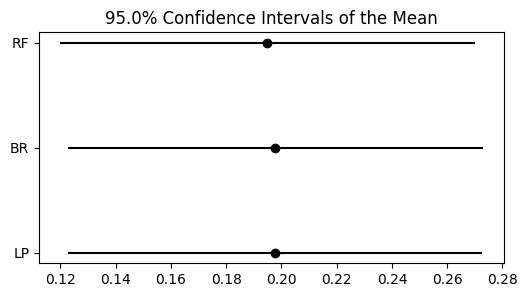


Wilcoxon: RF vs LP
p-valor: 0.0625


In [32]:
from autorank import autorank, plot_stats
from scipy.stats import wilcoxon
import matplotlib.pyplot as plt

print("\n===== HAMMING =====")

# tabela
df = build_table(all_results, "hamming")
#df = df.dropna()
df = df.drop(columns=["RAkEL"]) # RAkEL não funcionou com o dataset "flags" :/

print(df)

# Friedman + Nemenyi
result = autorank(df, alpha=0.05, order='ascending', verbose=True)

print("\nRanking médio:")
print(result.rankdf)

#plot_stats(result)
#plt.show()

plot_stats(result, allow_insignificant=True)
plt.show()

# Wilcoxon (só com os 2 melhores)
means = df.mean().sort_values(ascending=True)
m1, m2 = means.index[:2]

stat, p = wilcoxon(df[m1], df[m2])

print(f"\nWilcoxon: {m1} vs {m2}")
print("p-valor:", p)

Não foram observadas diferenças estatisticamente significativas entre os modelos (p = 0.520). Embora o Random Forest (RF) apresente o melhor ranking médio (menor Hamming Loss), as diferenças são negligenciáveis. O teste de Wilcoxon também não indicou diferença significativa entre os modelos comparados (p = 0.3125).

#### F1-score


===== F1_micro =====
                   BR        LP        RF
dataset                                  
flags        0.745971  0.750002  0.750636
CHD_49       0.663895  0.657633  0.663257
VirusGO      0.865424  0.851655  0.856026
emotions     0.683553  0.665726  0.675955
VirusPseAAC  0.231822  0.159421  0.196415
Fail to reject null hypothesis that data is normal for column BR (p=0.168391>=0.016667)
Fail to reject null hypothesis that data is normal for column LP (p=0.103283>=0.016667)
Fail to reject null hypothesis that data is normal for column RF (p=0.121056>=0.016667)
Using Bartlett's test for homoscedacity of normally distributed data
Fail to reject null hypothesis that all variances are equal (p=0.979676>=0.050000)
Fail to reject null hypothesis that there is no difference between the distributions (p=0.140393)
    meanrank      mean       std ci_lower ci_upper effect_size   magnitude  \
LP       2.8  0.616887  0.267468      NaN      NaN         0.0  negligible   
RF       1.8  

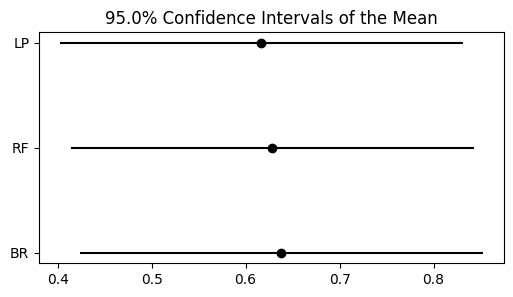


Wilcoxon: LP vs RF
p-valor: 0.0625


In [33]:
from autorank import autorank, plot_stats
from scipy.stats import wilcoxon
import matplotlib.pyplot as plt

print("\n===== F1_micro =====")

# tabela
df = build_table(all_results, "f1_micro")
#df = df.dropna()
df = df.drop(columns=["RAkEL"]) # RAkEL não funcionou com o dataset "flags" :/

print(df)

# Friedman + Nemenyi
result = autorank(df, alpha=0.05, order='descending', verbose=True)

print("\nRanking médio:")
print(result.rankdf)

#plot_stats(result)
#plt.show()

plot_stats(result, allow_insignificant=True)
plt.show()

# Wilcoxon (só com os 2 melhores)
means = df.mean().sort_values(ascending=True)
m1, m2 = means.index[:2]

stat, p = wilcoxon(df[m1], df[m2])

print(f"\nWilcoxon: {m1} vs {m2}")
print("p-valor:", p)

Conclusão: Não foram observadas diferenças estatisticamente significativas entre os modelos (p = 0.209). Embora o Binary Relevance (BR) apresente o melhor ranking médio, as diferenças são negligenciáveis. O teste de Wilcoxon também não indicou diferença significativa entre os modelos comparados (p = 0.125).


===== F1_macro =====
                   BR        LP        RF
dataset                                  
flags        0.626210  0.631145  0.623242
CHD_49       0.478881  0.453753  0.469685
VirusGO      0.827367  0.824306  0.831230
emotions     0.658552  0.635252  0.645180
VirusPseAAC  0.128124  0.103608  0.121353
Fail to reject null hypothesis that data is normal for column BR (p=0.601810>=0.016667)
Fail to reject null hypothesis that data is normal for column LP (p=0.561568>=0.016667)
Fail to reject null hypothesis that data is normal for column RF (p=0.625094>=0.016667)
Using Bartlett's test for homoscedacity of normally distributed data
Fail to reject null hypothesis that all variances are equal (p=0.998101>=0.050000)
Fail to reject null hypothesis that there is no difference between the distributions (p=0.050531)
    meanrank      mean       std ci_lower ci_upper effect_size   magnitude  \
LP       2.6  0.529613  0.271821      NaN      NaN         0.0  negligible   
RF       2.0  

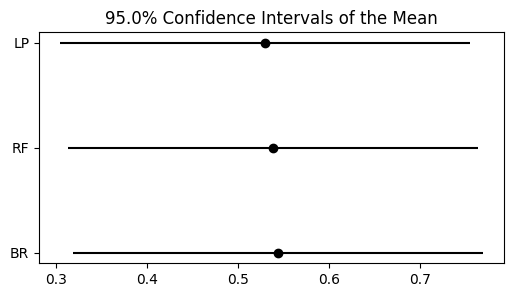


Wilcoxon: LP vs RF
p-valor: 0.1875


In [34]:
from autorank import autorank, plot_stats
from scipy.stats import wilcoxon
import matplotlib.pyplot as plt

print("\n===== F1_macro =====")

# tabela
df = build_table(all_results, "f1_macro")
#df = df.dropna()
df = df.drop(columns=["RAkEL"]) # RAkEL não funcionou com o dataset "flags" :/

print(df)

# Friedman + Nemenyi
result = autorank(df, alpha=0.05, order='descending', verbose=True)

print("\nRanking médio:")
print(result.rankdf)

#plot_stats(result)
#plt.show()

plot_stats(result, allow_insignificant=True)
plt.show()

# Wilcoxon (só com os 2 melhores)
means = df.mean().sort_values(ascending=True)
m1, m2 = means.index[:2]

stat, p = wilcoxon(df[m1], df[m2])

print(f"\nWilcoxon: {m1} vs {m2}")
print("p-valor:", p)

Conclusão:Foram observadas diferenças estatisticamente significativas entre os modelos (p = 0.016). O modelo Binary Relevance (BR) apresentou o melhor ranking médio, seguido por Random Forest (RF) e Label Powerset (LP). No entanto, os tamanhos de efeito são negligenciáveis. O teste de Wilcoxon entre os modelos comparados não indicou diferença significativa (p = 0.0625).

#### AUPRC


===== AUPRC_micro =====
                   BR        LP        RF
dataset                                  
flags        0.819811  0.815799  0.823154
CHD_49       0.697134  0.698144  0.698855
VirusGO      0.918240  0.930566  0.931603
emotions     0.755638  0.761754  0.757875
VirusPseAAC  0.414840  0.429111  0.423340
Fail to reject null hypothesis that data is normal for column BR (p=0.529787>=0.016667)
Fail to reject null hypothesis that data is normal for column LP (p=0.621877>=0.016667)
Fail to reject null hypothesis that data is normal for column RF (p=0.614225>=0.016667)
Using Bartlett's test for homoscedacity of normally distributed data
Fail to reject null hypothesis that all variances are equal (p=0.999382>=0.050000)
Fail to reject null hypothesis that there is no difference between the distributions (p=0.096824)
    meanrank      mean       std ci_lower ci_upper effect_size   magnitude  \
BR       2.8  0.721132  0.189849      NaN      NaN         0.0  negligible   
LP       1.

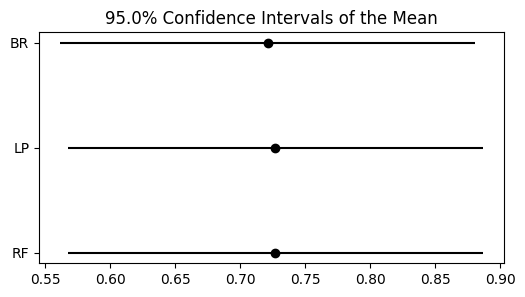


Wilcoxon: BR vs RF
p-valor: 0.0625


In [35]:
from autorank import autorank, plot_stats
from scipy.stats import wilcoxon
import matplotlib.pyplot as plt

print("\n===== AUPRC_micro =====")

# tabela
df = build_table(all_results, "auprc_micro")
#df = df.dropna()
df = df.drop(columns=["RAkEL"]) # RAkEL não funcionou com o dataset "flags" :/

print(df)

# Friedman + Nemenyi
result = autorank(df, alpha=0.05, order='descending', verbose=True)

print("\nRanking médio:")
print(result.rankdf)

#plot_stats(result)
#plt.show()

plot_stats(result, allow_insignificant=True)
plt.show()

# Wilcoxon (só com os 2 melhores)
means = df.mean().sort_values(ascending=True)
m1, m2 = means.index[:2]

stat, p = wilcoxon(df[m1], df[m2])

print(f"\nWilcoxon: {m1} vs {m2}")
print("p-valor:", p)

Conclusão: Não foram observadas diferenças estatisticamente significativas entre os modelos (p = 0.127). Apesar do Random Forest apresentar o melhor ranking médio, as diferenças são negligenciáveis. O teste de Wilcoxon também não indicou diferença significativa entre os modelos comparados (p = 0.1875).


===== AUPRC_macro =====
                   BR        LP        RF
dataset                                  
flags        0.748635  0.750365  0.757101
CHD_49       0.527054  0.524864  0.527963
VirusGO      0.933814  0.940206  0.937113
emotions     0.736315  0.751946  0.742954
VirusPseAAC  0.347833  0.392749  0.362377
Fail to reject null hypothesis that data is normal for column BR (p=0.827770>=0.016667)
Fail to reject null hypothesis that data is normal for column LP (p=0.752402>=0.016667)
Fail to reject null hypothesis that data is normal for column RF (p=0.815786>=0.016667)
Using Bartlett's test for homoscedacity of normally distributed data
Fail to reject null hypothesis that all variances are equal (p=0.994982>=0.050000)
Fail to reject null hypothesis that there is no difference between the distributions (p=0.171226)
    meanrank      mean       std ci_lower ci_upper effect_size   magnitude  \
BR       2.8  0.658730  0.225704      NaN      NaN         0.0  negligible   
LP       1.

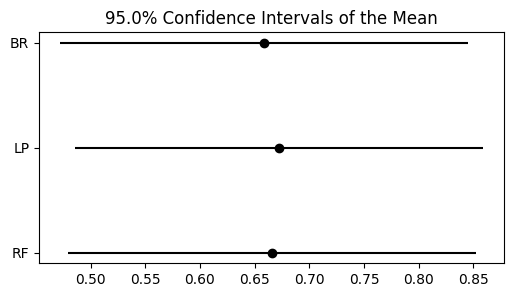


Wilcoxon: BR vs RF
p-valor: 0.0625


In [36]:
from autorank import autorank, plot_stats
from scipy.stats import wilcoxon
import matplotlib.pyplot as plt

print("\n===== AUPRC_macro =====")

# tabela
df = build_table(all_results, "auprc_macro")
#df = df.dropna()
df = df.drop(columns=["RAkEL"]) # RAkEL não funcionou com o dataset "flags" :/

print(df)

# Friedman + Nemenyi
result = autorank(df, alpha=0.05, order='descending', verbose=True)

print("\nRanking médio:")
print(result.rankdf)

#plot_stats(result)
#plt.show()

plot_stats(result, allow_insignificant=True)
plt.show()

# Wilcoxon (só com os 2 melhores)
means = df.mean().sort_values(ascending=True)
m1, m2 = means.index[:2]

stat, p = wilcoxon(df[m1], df[m2])

print(f"\nWilcoxon: {m1} vs {m2}")
print("p-valor:", p)

Conclusão: Não foram observadas diferenças estatisticamente significativas entre os modelos (p = 0.276). Embora o Random Forest apresente o melhor ranking médio, as diferenças são negligenciáveis. O teste de Wilcoxon também não indicou diferença significativa entre os modelos comparados (p = 0.625).

#### AUC


===== AUC_micro =====
                   BR        LP        RF
dataset                                  
flags        0.837149  0.836392  0.841750
CHD_49       0.787610  0.786645  0.788034
VirusGO      0.978911  0.980976  0.979770
emotions     0.873515  0.877240  0.876453
VirusPseAAC  0.771008  0.784072  0.781547
Fail to reject null hypothesis that data is normal for column BR (p=0.526062>=0.016667)
Fail to reject null hypothesis that data is normal for column LP (p=0.326914>=0.016667)
Fail to reject null hypothesis that data is normal for column RF (p=0.403771>=0.016667)
Using Bartlett's test for homoscedacity of normally distributed data
Fail to reject null hypothesis that all variances are equal (p=0.998658>=0.050000)
Fail to reject null hypothesis that there is no difference between the distributions (p=0.164889)
    meanrank      mean       std ci_lower ci_upper effect_size   magnitude  \
BR       2.6  0.849639  0.082867      NaN      NaN         0.0  negligible   
LP       1.8 

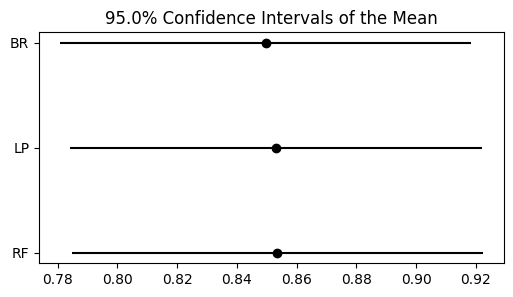


Wilcoxon: BR vs LP
p-valor: 0.3125


In [37]:
from autorank import autorank, plot_stats
from scipy.stats import wilcoxon
import matplotlib.pyplot as plt

print("\n===== AUC_micro =====")

# tabela
df = build_table(all_results, "auc_micro")
#df = df.dropna()
df = df.drop(columns=["RAkEL"]) # RAkEL não funcionou com o dataset "flags" :/

print(df)

# Friedman + Nemenyi
result = autorank(df, alpha=0.05, order='descending', verbose=True)

print("\nRanking médio:")
print(result.rankdf)

#plot_stats(result)
#plt.show()

plot_stats(result, allow_insignificant=True)
plt.show()

# Wilcoxon (só com os 2 melhores)
means = df.mean().sort_values(ascending=True)
m1, m2 = means.index[:2]

stat, p = wilcoxon(df[m1], df[m2])

print(f"\nWilcoxon: {m1} vs {m2}")
print("p-valor:", p)

Conclusão: Não foram observadas diferenças estatisticamente significativas entre os modelos (p = 0.265). Embora o Random Forest apresente o melhor ranking médio, as diferenças são negligenciáveis. O teste de Wilcoxon também não indicou diferença significativa entre os modelos comparados (p = 0.4375).


===== AUC_macro =====
                   BR        LP        RF
dataset                                  
flags        0.766022  0.756683  0.763526
CHD_49       0.604953  0.590578  0.593968
VirusGO      0.972884  0.977462  0.973816
emotions     0.851241  0.860713  0.858606
VirusPseAAC  0.594200  0.650771  0.613199
Fail to reject null hypothesis that data is normal for column BR (p=0.531851>=0.016667)
Fail to reject null hypothesis that data is normal for column LP (p=0.866322>=0.016667)
Fail to reject null hypothesis that data is normal for column RF (p=0.590151>=0.016667)
Using Bartlett's test for homoscedacity of normally distributed data
Fail to reject null hypothesis that all variances are equal (p=0.997097>=0.050000)
Fail to reject null hypothesis that there is no difference between the distributions (p=0.589606)
    meanrank      mean       std ci_lower ci_upper effect_size   magnitude  \
BR       2.2  0.757860  0.162163      NaN      NaN         0.0  negligible   
RF       2.0 

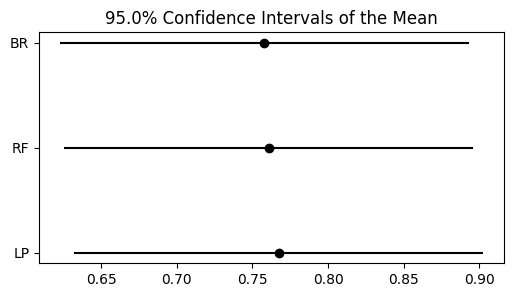


Wilcoxon: BR vs RF
p-valor: 0.8125


In [38]:
from autorank import autorank, plot_stats
from scipy.stats import wilcoxon
import matplotlib.pyplot as plt

print("\n===== AUC_macro =====")

# tabela
df = build_table(all_results, "auc_macro")
#df = df.dropna()
df = df.drop(columns=["RAkEL"]) # RAkEL não funcionou com o dataset "flags" :/

print(df)

# Friedman + Nemenyi
result = autorank(df, alpha=0.05, order='descending', verbose=True)

print("\nRanking médio:")
print(result.rankdf)

#plot_stats(result)
#plt.show()

plot_stats(result, allow_insignificant=True)
plt.show()

# Wilcoxon (só com os 2 melhores)
means = df.mean().sort_values(ascending=True)
m1, m2 = means.index[:2]

stat, p = wilcoxon(df[m1], df[m2])

print(f"\nWilcoxon: {m1} vs {m2}")
print("p-valor:", p)

Conclusão: Para a métrica AUC Macro, os testes estatísticos indicaram que não há diferenças estatisticamente significativas entre os modelos avaliados (p = 0.825). Embora o modelo Random Forest tenha apresentado o melhor ranking médio, o tamanho de efeito foi considerado negligenciável. O teste de Wilcoxon entre os dois melhores modelos também não identificou diferença significativa (p = 1.0), reforçando que os desempenhos são equivalentes.